# Helios 02 — Visual Basemap: NAIP aerial imagery to raster PMTiles

**Solar site-selection, step 2: the visual context.** Before scoring roofs, we want
to *see* them. This notebook stages **NAIP** (National Agriculture Imagery Program)
aerial imagery covering San Francisco — fanning out across the *several real NAIP
quads* that tile the city — then builds an **XYZ tile pyramid** straight from those
quads with the **`pmtiles_gbx`** raster reader (per-tile mosaic reads: each output
tile composites the quads that cover it, so the basemap stays seamless and memory
stays bounded per tile), and writes the pyramid to a single raster **PMTiles** archive
with the matching `pmtiles_gbx` writer — read and write are the same tile family, so
nothing glues between them. We view it with `plot_pmtiles`. This aerial basemap sits
behind the building footprints from notebook 01 and covers the same SF area.

> Runs on the **lightweight tier (Serverless)** by default.
---
_Last Modified:_ June 29, 2026

![NAIP aerial to raster PMTiles](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/helios/helios-02.png)

In [0]:
%run ./config_nb

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... skipping spark.conf.set(spark.sql.adaptive.coalescePartitions.enabled) [Serverless?]: AnalysisException


True

... catalog: 'geospatial_docs' (USE)
... schema: 'geobrix' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/geobrix/data'
... HELIOS_DIR: '/Volumes/geospatial_docs/geobrix/data/helios' (MKDIRS)
... SF_CITY_BBOX: (-122.52, 37.7, -122.35, 37.83)


In [0]:
# Toggles (also overridable per-notebook in a cell right after %run ./config_nb):
FORCE_REBUILD = False      # True (default False) -> re-create tables / re-download / re-tile (skip-guards off)
INTERACTIVE_PLOTS = False  # False (default) -> fast static maps that render on GitHub; True -> interactive maps

## 1. Stage NAIP aerial imagery (product `NaipDownloader`)

NAIP is STAC on Planetary Computer. We dogfood the product **`NaipDownloader`** (a thin
`gbx.sample` client over `StacClient`): one call searches every NAIP quad intersecting the
SF AOI, keeps the most recent vintage (same-year, disjoint quads), and **windows + decimates
each quad to the AOI on read** (`bbox` + `max_mpp` → the COG's 2.4 m overview), fanning the
download out across the quads in parallel. The result is several real NAIP GeoTIFFs in
`NAIP_DIR` tiling the city — correct georeferencing handled in-product, no hand-rolled glue.


In [0]:
import glob
import os

from databricks.labs.gbx.sample import download_naip_aoi

NAIP_DIR = f"{HELIOS_DIR}/naip"
os.makedirs(NAIP_DIR, exist_ok=True)   # Volume FUSE-safe; idempotent

# Decimate each windowed quad to this resolution (max metres-per-pixel, source CRS).
# 2.4 m = factor 4 over NAIP's native 0.6 m -> reads the COG's 2.4 m overview directly:
# small per-quad transfer, ample for a city basemap.
NAIP_MAX_MPP = 2.4

# Skip-guard: reuse already-staged quads unless FORCE_REBUILD.
_existing = sorted(glob.glob(f"{NAIP_DIR}/*.tif"))
if _existing and not FORCE_REBUILD:
    NAIP_PATHS = _existing
    print(f"... NAIP already staged ({len(NAIP_PATHS)} quad(s)) in {NAIP_DIR}")
else:
    for _p in _existing:      # clear stale quads so a changed AOI / vintage can't leave orphans
        os.remove(_p)
    # NaipDownloader (wraps StacClient): search -> latest vintage -> windowed + decimated,
    # parallel per-quad download. One call replaces the old hand-rolled staging.
    _staged = download_naip_aoi(spark, SF_CITY_BBOX, NAIP_DIR, year="latest", max_mpp=NAIP_MAX_MPP)
    NAIP_PATHS = sorted(
        r["out_file_path"] for r in _staged.collect()
        if r["is_out_file_valid"] and r["out_file_path"]
    )
    print(f"... staged {len(NAIP_PATHS)} NAIP quad(s) -> {NAIP_DIR}")

NAIP_PATH = NAIP_PATHS[0]   # representative quad for the §2 preview


... NAIP already staged (12 quad(s)) in /Volumes/geospatial_docs/geobrix/data/helios/naip


## 2. Preview the source imagery

`plot_file` renders one staged NAIP quad straight from the Volume (auto-decimation,
per-band percentile stretch). Several quads tile the full SF AOI; this is a static
single-source preview of the first (a raw source raster has no tiled interactive
form). The tiled PMTiles **product** is what the `INTERACTIVE_PLOTS` toggle governs
at the view step below.


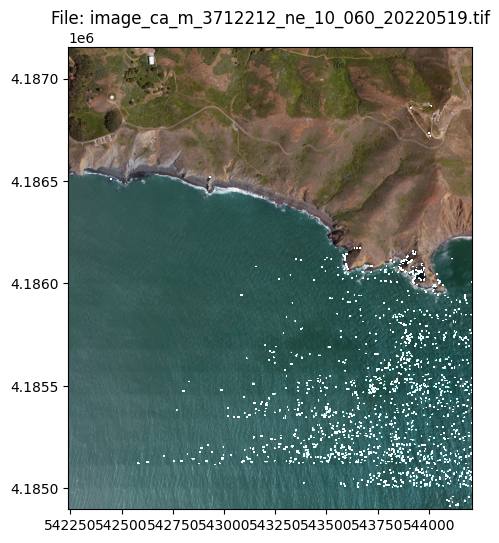

In [0]:
plot_file(NAIP_PATH, fig_w=8, fig_h=6)

## 3. Build the XYZ tile pyramid (`pmtiles_gbx` raster reader)

Merging the quads into one raster and pyramiding it would load the whole city into a
single task → the Serverless per-UDF memory wall. The **`pmtiles_gbx`** raster reader
takes the scalable path instead: it enumerates the slippy-map tiles for the AOI and
renders **each tile's 256² window directly from the NAIP quads**, compositing the quads
that cover that tile (rio-tiler `mosaic_reader`). Memory is bounded per tile, the work
fans out across `InputPartition`s, and because every `(z, x, y)` is produced once from
all its covering quads the basemap is seamless — no per-quad pyramiding, no first-wins
boundary seams.

The reader handles the cluster-correctness details in-product: it sets up the GDAL/PROJ
env, stages each quad's bytes **sequentially** (UC Volume FUSE can't serve the random
window seeks a direct path read needs), and composites serially per tile. One `.load()`
replaces the hand-rolled enumerate-tiles + per-tile-UDF + `spark.range` glue.


In [0]:
# Start the pyramid a few levels below the city so there's a low-zoom OVERVIEW: the
# interactive viewer frames the whole AOI by fitting the archive bounds, and MapLibre
# can't zoom out below the archive's min level — z10 gives it room to open on the full city.
MIN_Z, MAX_Z = 10, 16

# pmtiles_gbx raster reader: enumerate (z,x,y) for the AOI and render each tile by
# per-tile mosaic over the NAIP quads in NAIP_DIR. bbox is "minx,miny,maxx,maxy" in
# EPSG:4326; the reader fans out across InputPartitions (no spark.range/repartition
# trick needed). Output is exactly (z, x, y, bytes) -> feeds the writer directly.
# Registered by rx.register(spark) in config_nb.
xyz = (
    spark.read.format("pmtiles_gbx")
         .option("source", "raster")
         .option("path", NAIP_DIR)
         .option("bbox", ",".join(str(v) for v in SF_CITY_BBOX))
         .option("minZoom", str(MIN_Z))
         .option("maxZoom", str(MAX_Z))
         .load()
)
sf_xyz = finalize_delta(xyz, "sf_naip_xyz_tiles")
print(f"... {sf_xyz.count():,} (z,x,y) raster tiles across z{MIN_Z}-z{MAX_Z}")


... table sf_naip_xyz_tiles exists (skip; FORCE_REBUILD=False)
root
 |-- z: integer (nullable = true)
 |-- x: integer (nullable = true)
 |-- y: integer (nullable = true)
 |-- bytes: binary (nullable = true)

... 1,379 (z,x,y) raster tiles across z10-z16


## 4. Package as raster PMTiles

The reader's `(z, x, y, bytes)` output is exactly what the **`pmtiles_gbx`** writer
takes — same tile family, so the pyramid flows straight into the archive with no
reshaping. With `shardZoom=0` the writer emits a single self-contained `.pmtiles`
archive (auto-detecting the PNG tile type). Each `(z, x, y)` was already composited
from all its covering quads at read time, so the archive is seamless with no dropped
or split tiles.


In [0]:
# pmtiles_gbx writer: requires exactly columns (z:int, x:int, y:int, bytes:binary).
# shardZoom=0 -> a single .pmtiles archive (vs the default sharded tileset directory).
# It is registered by rx.register(spark) in config_nb.
TILES_DIR = f"{HELIOS_DIR}/tiles"
os.makedirs(TILES_DIR, exist_ok=True)   # Volume FUSE-safe sequential write from driver
NAIP_PMTILES = f"{TILES_DIR}/sf_naip.pmtiles"

# Skip-guard: write the archive ONCE; reuse on re-runs unless FORCE_REBUILD.
if FORCE_REBUILD or not os.path.exists(NAIP_PMTILES):
    (
        sf_xyz.select("z", "x", "y", "bytes")
              .write.format("pmtiles_gbx")
              .option("shardZoom", "0")
              .mode("overwrite")
              .save(NAIP_PMTILES)
    )
    print(f"... wrote {NAIP_PMTILES} ({os.path.getsize(NAIP_PMTILES):,} bytes)")
else:
    print(f"... {NAIP_PMTILES} exists (skip; FORCE_REBUILD=False)")


... /Volumes/geospatial_docs/geobrix/data/helios/tiles/sf_naip.pmtiles exists (skip; FORCE_REBUILD=False)


## 5. View the raster PMTiles inline

`show_pmtiles` renders through the `INTERACTIVE_PLOTS` toggle — a static image by default, or an interactive MapLibre raster layer when `INTERACTIVE_PLOTS = True`.

_Turned off `INTERACTIVE_PLOTS` for GitHub/docs rendering of ipynb export._

... pmtiles: type=png zoom=12-16 bounds=(-122.6074219, 37.649034, -122.34375, 37.8575072)
[vizx] layer[0] 0.0MB = 179.0MB > 0MB → static fallback


<Axes: >

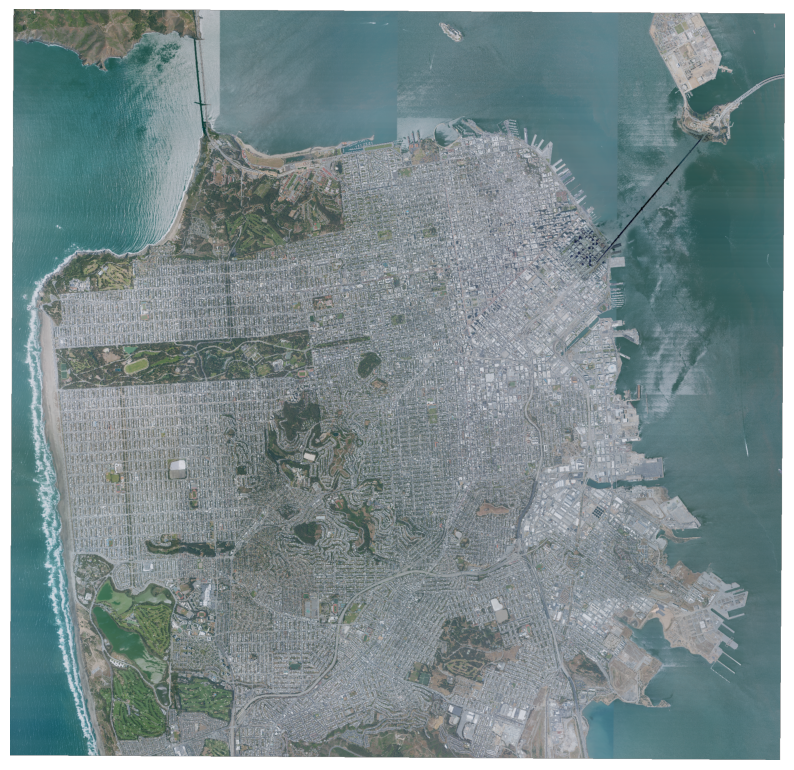

In [0]:
show_pmtiles(NAIP_PMTILES)

## 6. Overlay: aerial basemap + building footprints

When `INTERACTIVE_PLOTS = True`, `plot_interactive` layers the NAIP raster PMTiles as
the basemap and the NB01 building-footprint PMTiles on top — both archives embedded
in-browser via MapLibre GL, no tile server required. The buildings layer degrades
gracefully when notebook 01 has not run yet (the guard checks for the file). 

_Turned off `INTERACTIVE_PLOTS` for GitHub/docs rendering of ipynb export._

In [0]:
# Multi-layer overlay: NAIP aerial basemap + NB01 building footprints.
# pmtiles_layer / plot_interactive come from gbx.vizx (same package as plot_pmtiles).
# Prefer NB01's simplified buildings OVERVIEW: the full sf_buildings.pmtiles is z12-16
# with no low-zoom level and won't embed interactively; the overview (built in NB01 §6
# when INTERACTIVE_PLOTS) does. Fall back to the full archive if the overview is absent.
from databricks.labs.gbx.vizx import pmtiles_layer, plot_interactive as _plot_interactive

BUILDINGS_OVERVIEW = f"{TILES_DIR}/sf_buildings_overview.pmtiles"
BUILDINGS_PMTILES = f"{TILES_DIR}/sf_buildings.pmtiles"
_buildings = BUILDINGS_OVERVIEW if os.path.exists(BUILDINGS_OVERVIEW) else BUILDINGS_PMTILES

if INTERACTIVE_PLOTS:
    _layers = [pmtiles_layer(NAIP_PMTILES, label="NAIP aerial")]
    if os.path.exists(_buildings):
        _layers.append(pmtiles_layer(_buildings, label="buildings"))
    _plot_interactive(_layers)
else:
    print("... set INTERACTIVE_PLOTS = True to render the multi-layer MapLibre overlay")

... set INTERACTIVE_PLOTS = True to render the multi-layer MapLibre overlay


## What we built

- `sf_naip_xyz_tiles` (Delta) — one row per `(z, x, y)` PNG tile.
- `sf_naip.pmtiles` (Volume) — a self-contained aerial basemap.

Next: **notebook 03** adds the analytical layer — terrain slope and aspect from a
USGS 3DEP DEM, the inputs to a solar suitability score.